In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris

In [2]:
data = load_iris()
df = pd.DataFrame(data.data,columns=data.feature_names)
df['Species'] = data.target

In [3]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
df = df.iloc[:,1:]

In [5]:
df.head()

,sepal width (cm),petal length (cm),petal width (cm),Species
0,3.5,1.4,0.2,0
1,3.0,1.4,0.2,0
2,3.2,1.3,0.2,0
3,3.1,1.5,0.2,0
4,3.6,1.4,0.2,0


In [6]:
from sklearn.preprocessing import LabelEncoder

In [7]:
encoder = LabelEncoder()

In [8]:
df['Species'] = encoder.fit_transform(df['Species'])

In [9]:
df.head()

,sepal width (cm),petal length (cm),petal width (cm),Species
0,3.5,1.4,0.2,0
1,3.0,1.4,0.2,0
2,3.2,1.3,0.2,0
3,3.1,1.5,0.2,0
4,3.6,1.4,0.2,0


In [11]:
df = df[df['Species'] != 0][['sepal width (cm)','petal length (cm)','Species']]

In [13]:
df.head()

,sepal width (cm),petal length (cm),Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

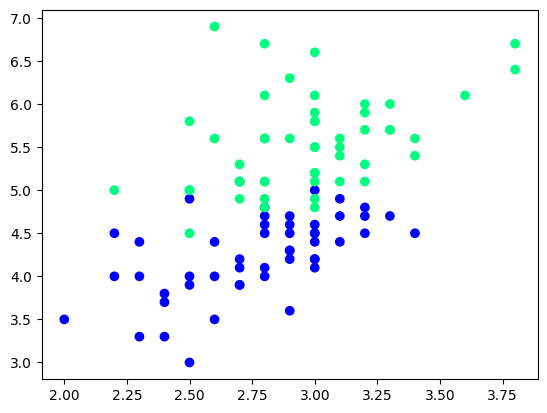

In [16]:
plt.scatter(df['sepal width (cm)'],df['petal length (cm)'],c=df['Species'],cmap='winter')

In [17]:
df_train = df.iloc[:60,:].sample(10)
df_train

,sepal width (cm),petal length (cm),Species
59,2.7,3.9,1
94,2.7,4.2,1
75,3.0,4.4,1
56,3.3,4.7,1
53,2.3,4.0,1
97,2.9,4.3,1
102,3.0,5.9,2
95,3.0,4.2,1
84,3.0,4.5,1
89,2.5,4.0,1


In [18]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [19]:
df_train

,sepal width (cm),petal length (cm),Species
134,2.6,5.6,2
149,3.0,5.1,2
120,3.2,5.7,2
115,3.2,5.3,2
59,2.7,3.9,1
84,3.0,4.5,1
62,2.2,4.0,1
126,2.8,4.8,2
138,3.0,4.8,2
123,2.7,4.9,2


In [20]:
df_val

,sepal width (cm),petal length (cm),Species
72,2.5,4.9,1
146,2.5,5.0,2
67,2.7,4.1,1
58,2.9,4.6,1
121,2.8,4.9,2


In [21]:
df_test

,sepal width (cm),petal length (cm),Species
100,3.3,6.0,2
70,3.2,4.8,1
52,3.1,4.9,1
86,3.1,4.7,1
119,2.2,5.0,2


In [22]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [23]:
y_test

array([1, 2, 1, 1, 2])

In [27]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))


# Case 1 - Bagging

In [24]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal width (cm),petal length (cm),Species
59,2.7,3.9,1
120,3.2,5.7,2
138,3.0,4.8,2
134,2.6,5.6,2
115,3.2,5.3,2
115,3.2,5.3,2
126,2.8,4.8,2
120,3.2,5.7,2


In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [26]:
dt_bag1 = DecisionTreeClassifier()

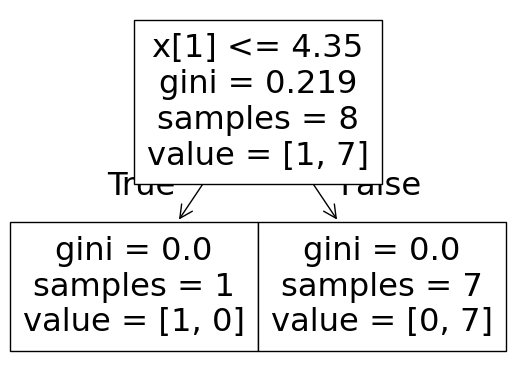

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.6


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


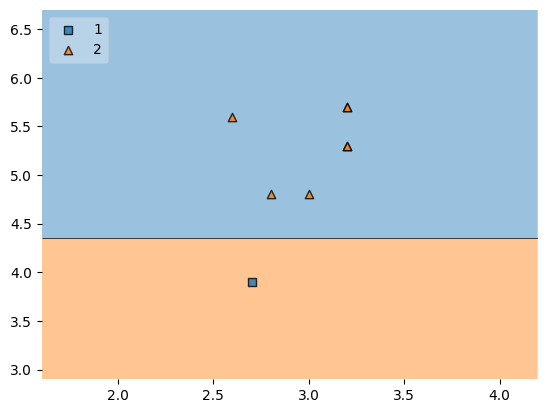

In [28]:
evaluate(dt_bag1,X,y)

In [29]:
# Data for Tree 2
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal width (cm),petal length (cm),Species
115,3.2,5.3,2
62,2.2,4.0,1
84,3.0,4.5,1
138,3.0,4.8,2
123,2.7,4.9,2
138,3.0,4.8,2
149,3.0,5.1,2
115,3.2,5.3,2


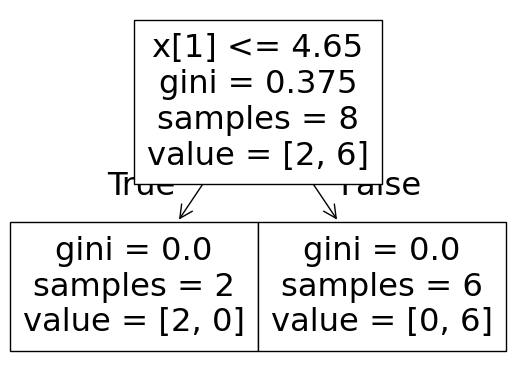

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


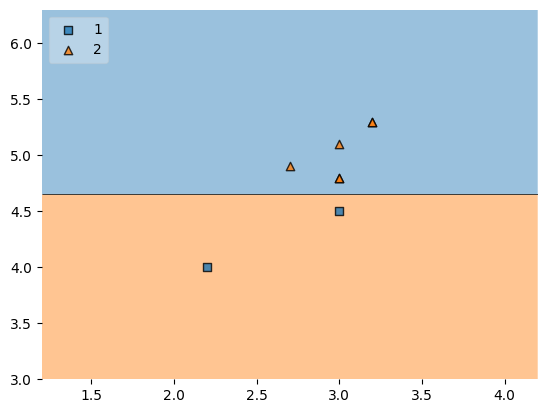

In [30]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [31]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal width (cm),petal length (cm),Species
59,2.7,3.9,1
115,3.2,5.3,2
115,3.2,5.3,2
138,3.0,4.8,2
138,3.0,4.8,2
120,3.2,5.7,2
123,2.7,4.9,2
138,3.0,4.8,2


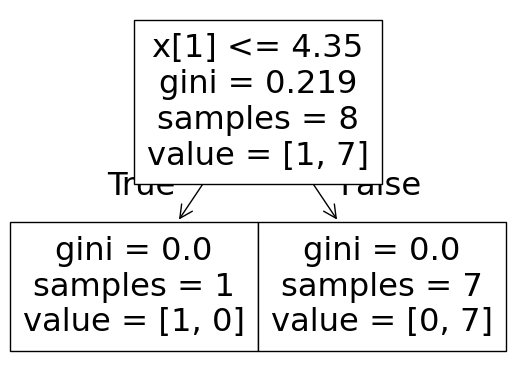

0.6


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


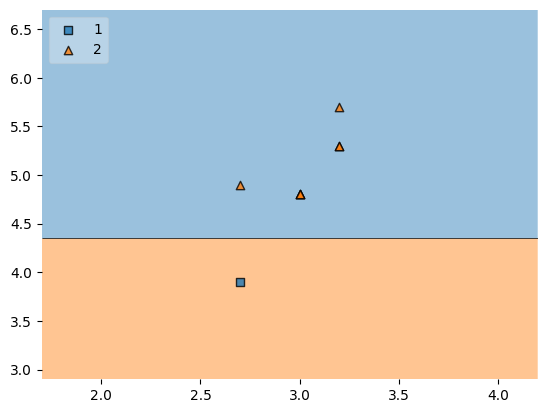

In [32]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

## Predict

In [33]:
df_test

,sepal width (cm),petal length (cm),Species
100,3.3,6.0,2
70,3.2,4.8,1
52,3.1,4.9,1
86,3.1,4.7,1
119,2.2,5.0,2


In [35]:
print("Predictor 1",dt_bag1.predict(np.array([3.2,4.8]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([3.2,4.8]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([3.2,4.8]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [2]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Pasting

In [36]:
# Row sampling without replacement
df_train

,sepal width (cm),petal length (cm),Species
134,2.6,5.6,2
149,3.0,5.1,2
120,3.2,5.7,2
115,3.2,5.3,2
59,2.7,3.9,1
84,3.0,4.5,1
62,2.2,4.0,1
126,2.8,4.8,2
138,3.0,4.8,2
123,2.7,4.9,2


In [37]:
df_train.sample(8)

,sepal width (cm),petal length (cm),Species
84,3.0,4.5,1
126,2.8,4.8,2
123,2.7,4.9,2
62,2.2,4.0,1
59,2.7,3.9,1
120,3.2,5.7,2
138,3.0,4.8,2
115,3.2,5.3,2


# Random Subspaces

In [38]:
df1 = pd.read_csv('/kaggle/input/iris/Iris.csv')
df1 = df1.sample(10)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/iris/Iris.csv'

In [ ]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
134,135,6.1,2.6,5.6,1.4,Iris-virginica
12,13,4.8,3.0,1.4,0.1,Iris-setosa
13,14,4.3,3.0,1.1,0.1,Iris-setosa
146,147,6.3,2.5,5.0,1.9,Iris-virginica
38,39,4.4,3.0,1.3,0.2,Iris-setosa
62,63,6.0,2.2,4.0,1.0,Iris-versicolor
77,78,6.7,3.0,5.0,1.7,Iris-versicolor
45,46,4.8,3.0,1.4,0.3,Iris-setosa
109,110,7.2,3.6,6.1,2.5,Iris-virginica
10,11,5.4,3.7,1.5,0.2,Iris-setosa


In [ ]:
df1.sample(2,replace=True,axis=1)

,SepalWidthCm,Species
134,2.6,Iris-virginica
12,3.0,Iris-setosa
13,3.0,Iris-setosa
146,2.5,Iris-virginica
38,3.0,Iris-setosa
62,2.2,Iris-versicolor
77,3.0,Iris-versicolor
45,3.0,Iris-setosa
109,3.6,Iris-virginica
10,3.7,Iris-setosa


# Random Patches

In [ ]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
134,135,6.1,2.6,5.6,1.4,Iris-virginica
12,13,4.8,3.0,1.4,0.1,Iris-setosa
13,14,4.3,3.0,1.1,0.1,Iris-setosa
146,147,6.3,2.5,5.0,1.9,Iris-virginica
38,39,4.4,3.0,1.3,0.2,Iris-setosa
62,63,6.0,2.2,4.0,1.0,Iris-versicolor
77,78,6.7,3.0,5.0,1.7,Iris-versicolor
45,46,4.8,3.0,1.4,0.3,Iris-setosa
109,110,7.2,3.6,6.1,2.5,Iris-virginica
10,11,5.4,3.7,1.5,0.2,Iris-setosa


In [ ]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,SepalLengthCm,Id
38,4.4,39
10,5.4,11
109,7.2,110
62,6.0,63
134,6.1,135
12,4.8,13
10,5.4,11
134,6.1,135
